# Handwriting Recognition: End-to-End Pipeline

Data preprocessing, model architectures, training, and the inference demo, in one run.

**Two recognition pathways:**
- **Pathway A (CRNN + CTC)** - trained in this notebook (Part 4), or loaded from an existing checkpoint.
- **Pathway B (HTR-VT)** - a separately-trained transformer model; this notebook loads its checkpoint but does not train it.

**Before running:** place any checkpoint files you already have in `checkpoints/`
(created automatically if missing) in the **same folder as this notebook**:
- `checkpoints/crnn_model.pt` - Pathway A weights
- `checkpoints/best_vit.pt` and `checkpoints/vocab.json` - Pathway B (HTR-VT) weights + its vocabulary

If `checkpoints/crnn_model.pt` isn't present, **Run All** trains Pathway A from scratch
(Part 4) instead of loading it. Training data loads directly from the `Teklia/IAM-line`
dataset on Hugging Face - no Kaggle token or Google Drive needed.


In [37]:
import os

# All checkpoint / .pt files live in checkpoints/, alongside this notebook.
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CRNN_CHECKPOINT_FILE = os.path.join(CHECKPOINT_DIR, "crnn_model.pt")
CRNN_INT8_CHECKPOINT_FILE = os.path.join(CHECKPOINT_DIR, "crnn_model_int8.pt")
CRNN_TRAINING_CHECKPOINT_FILE = os.path.join(CHECKPOINT_DIR, "crnn_training_checkpoint.pt")
VIT_CHECKPOINT_FILE = os.path.join(CHECKPOINT_DIR, "best_vit.pt")           # HTR-VT weights (Pathway B)
VIT_VOCAB_FILE = os.path.join(CHECKPOINT_DIR, "vocab.json")            # HTR-VT vocabulary (Pathway B)

print(f"--> Checkpoint directory ready: ./{CHECKPOINT_DIR}/")


--> Checkpoint directory ready: ./checkpoints/


In [38]:
!pip install -q transformers gradio datasets

In [39]:
import os
import json
import time
import random
import string
import shutil

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from skimage.filters import threshold_sauvola
import albumentations as A
from transformers import (
    VisionEncoderDecoderModel, VisionEncoderDecoderConfig, ViTConfig, TrOCRConfig
)
from tqdm import tqdm
import gradio as gr

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--> Running on device: {device}")

--> Running on device: cpu


# **Part 1 - Data Preprocessing**

## **Step 1: Character Vocabulary**

In [40]:
# Full charset: upper/lowercase letters, digits, space, and punctuation
PUNCTUATION = ' .,-!?"#()*/:;+&' + "'"
CHARSET = list(string.ascii_uppercase + string.ascii_lowercase + string.digits + PUNCTUATION)

# Reserve index 0 for the CTC blank token
char_to_idx = {ch: idx + 1 for idx, ch in enumerate(CHARSET)}
idx_to_char = {idx: ch for ch, idx in char_to_idx.items()}
idx_to_char[0] = ''  # CTC blank

NUM_CLASSES = len(CHARSET) + 1
print(f"--> Vocabulary built: {len(CHARSET)} characters + 1 blank = {NUM_CLASSES} classes")


def encode_label(text: str) -> torch.Tensor:
    """Converts a text string into a LongTensor of character indices.
    Characters outside the vocabulary are silently dropped (and should be rare
    if the vocabulary was chosen to match the target dataset)."""
    indices = [char_to_idx[ch] for ch in text if ch in char_to_idx]
    return torch.tensor(indices, dtype=torch.long)


def decode_label(indices) -> str:
    """Converts a sequence of class indices back into a text string."""
    return "".join(idx_to_char.get(int(i), '') for i in indices)


# Sanity check: round-trip encode/decode
_test = "Hello, World!"
assert decode_label(encode_label(_test)) == _test
print(f"--> Round-trip check passed for: '{_test}'")

--> Vocabulary built: 79 characters + 1 blank = 80 classes
--> Round-trip check passed for: 'Hello, World!'


## **Step 2: Data Ingestion (Hugging Face IAM-line)**

In [41]:
from datasets import load_dataset

# Load the line-level dataset directly from Hugging Face
print("--> Loading Teklia/IAM-line from Hugging Face...")
hf_dataset = load_dataset("Teklia/IAM-line")

# Convert splits to Pandas DataFrames
train_df = hf_dataset['train'].to_pandas()
val_df = hf_dataset['validation'].to_pandas()

# Teklia/IAM-line uses 'image' (dict containing bytes/PIL Image) and 'text'
# Standardize column name to 'label' for compatibility with downstream functions
train_df = train_df.rename(columns={'text': 'label'})
val_df = val_df.rename(columns={'text': 'label'})

print(f"--> Total train samples: {len(train_df)} | Total validation samples: {len(val_df)}")

--> Loading Teklia/IAM-line from Hugging Face...
--> Total train samples: 6482 | Total validation samples: 976


## **Step 6: Preprocessing, Augmentation, Dataset, and DataLoaders**

Builds `BaselinePreprocessor`, `HandwritingDataset`, both collate functions
(`ctc_collate_fn` for Pathway A, `vit_collate_fn` for Pathway B), and all four
DataLoaders in one place: this is the version that ended up self-contained
across the later notebooks, consolidated here instead of being rebuilt three
separate times.

In [42]:
import random
import numpy as np
import cv2
import torch
import albumentations as A
import pandas as pd
from torch.utils.data import Dataset, DataLoader

CHAR_HEIGHT = 64
MAX_WIDTH = 1024
BATCH_SIZE = 32

class BaselinePreprocessor:
    def __init__(self, target_height: int = CHAR_HEIGHT, max_width: int = MAX_WIDTH):
        self.target_height = target_height
        self.max_width = max_width

    def apply_contrast_normalization(self, image: np.ndarray) -> np.ndarray:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        return clahe.apply(image)

    def apply_binarization(self, image: np.ndarray) -> np.ndarray:
        if np.mean(image) < 127:  # Invert back if input image background is dark
            image = cv2.bitwise_not(image)

        _, binary_img = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return cv2.bitwise_not(binary_img)  # White text on black background

    def apply_morphology(self, binary_img: np.ndarray) -> np.ndarray:
        kernel = np.ones((2, 2), np.uint8)
        inverted = cv2.bitwise_not(binary_img)
        processed_img = cv2.morphologyEx(inverted, cv2.MORPH_CLOSE, kernel)
        return cv2.bitwise_not(processed_img)

    def resize(self, image: np.ndarray) -> np.ndarray:
        h, w = image.shape[:2]
        scale = self.target_height / h
        new_w = min(max(1, int(w * scale)), self.max_width)
        return cv2.resize(image, (new_w, self.target_height), interpolation=cv2.INTER_CUBIC)

    def __call__(self, image: np.ndarray) -> np.ndarray:
        image = self.apply_contrast_normalization(image)  # CLAHE added to pipeline
        image = self.apply_binarization(image)
        image = self.apply_morphology(image)
        image = self.resize(image)
        return image


def get_training_augmentations(max_elastic_sigma: float = 4.0) -> A.Compose:
    return A.Compose([
        # fill=0 fills padded borders with background black (0) instead of ink white (255)
        A.Affine(shear=(-15, 15), p=0.6, border_mode=cv2.BORDER_CONSTANT, fill=0),
        A.ElasticTransform(alpha=35.0, sigma=max_elastic_sigma, p=0.6, border_mode=cv2.BORDER_CONSTANT, fill=0),
        A.MotionBlur(blur_limit=5, p=0.3),
    ])


class HandwritingDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, preprocessor=None, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        raw_img = row['image']
        if isinstance(raw_img, dict) and 'bytes' in raw_img:
            nparr = np.frombuffer(raw_img['bytes'], np.uint8)
            image = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)
        elif hasattr(raw_img, 'convert'):
            image = np.array(raw_img.convert('L'))
        else:
            image = np.array(raw_img, dtype=np.uint8)

        if self.preprocessor:
            image = self.preprocessor(image)
        if self.transform:
            image = self.transform(image=image)['image']

        if not torch.is_tensor(image):
            image = torch.from_numpy(image).unsqueeze(0).float() / 255.0

        return image, encode_label(row['label'])


def ctc_collate_fn(batch):
    images, labels = zip(*batch)
    heights = {img.shape[1] for img in images}
    assert len(heights) == 1, "All images in a batch must share the same height"
    target_height = heights.pop()
    max_width = max(img.shape[2] for img in images)

    padded_images = torch.zeros(len(images), 1, target_height, max_width)  # Zero-padded (black background)
    for i, img in enumerate(images):
        padded_images[i, :, :, :img.shape[2]] = img

    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    labels_concat = torch.cat(labels) if len(labels) > 0 else torch.tensor([], dtype=torch.long)
    return padded_images, labels_concat, label_lengths


def vit_collate_fn(batch):
    images, labels = zip(*batch)
    padded_images = torch.zeros(len(images), 1, CHAR_HEIGHT, MAX_WIDTH)  # Zero-padded (black background)
    for i, img in enumerate(images):
        w = min(img.shape[2], MAX_WIDTH)
        padded_images[i, :, :, :w] = img[:, :, :w]
    return padded_images, list(labels)


# Instantiate pipeline
baseline_preprocessor = BaselinePreprocessor(target_height=CHAR_HEIGHT, max_width=MAX_WIDTH)
train_augmentations = get_training_augmentations(max_elastic_sigma=4.0)

train_dataset = HandwritingDataset(train_df, preprocessor=baseline_preprocessor, transform=train_augmentations)
val_dataset = HandwritingDataset(val_df, preprocessor=baseline_preprocessor, transform=None)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True, collate_fn=ctc_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True, collate_fn=ctc_collate_fn)

vit_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=True, drop_last=True, collate_fn=vit_collate_fn)
vit_val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True, collate_fn=vit_collate_fn)

print(f"--> CTC loaders: {len(train_loader)} train / {len(val_loader)} val batches")
print(f"--> ViT loaders: {len(vit_train_loader)} train / {len(vit_val_loader)} val batches")

--> CTC loaders: 202 train / 31 val batches
--> ViT loaders: 202 train / 31 val batches


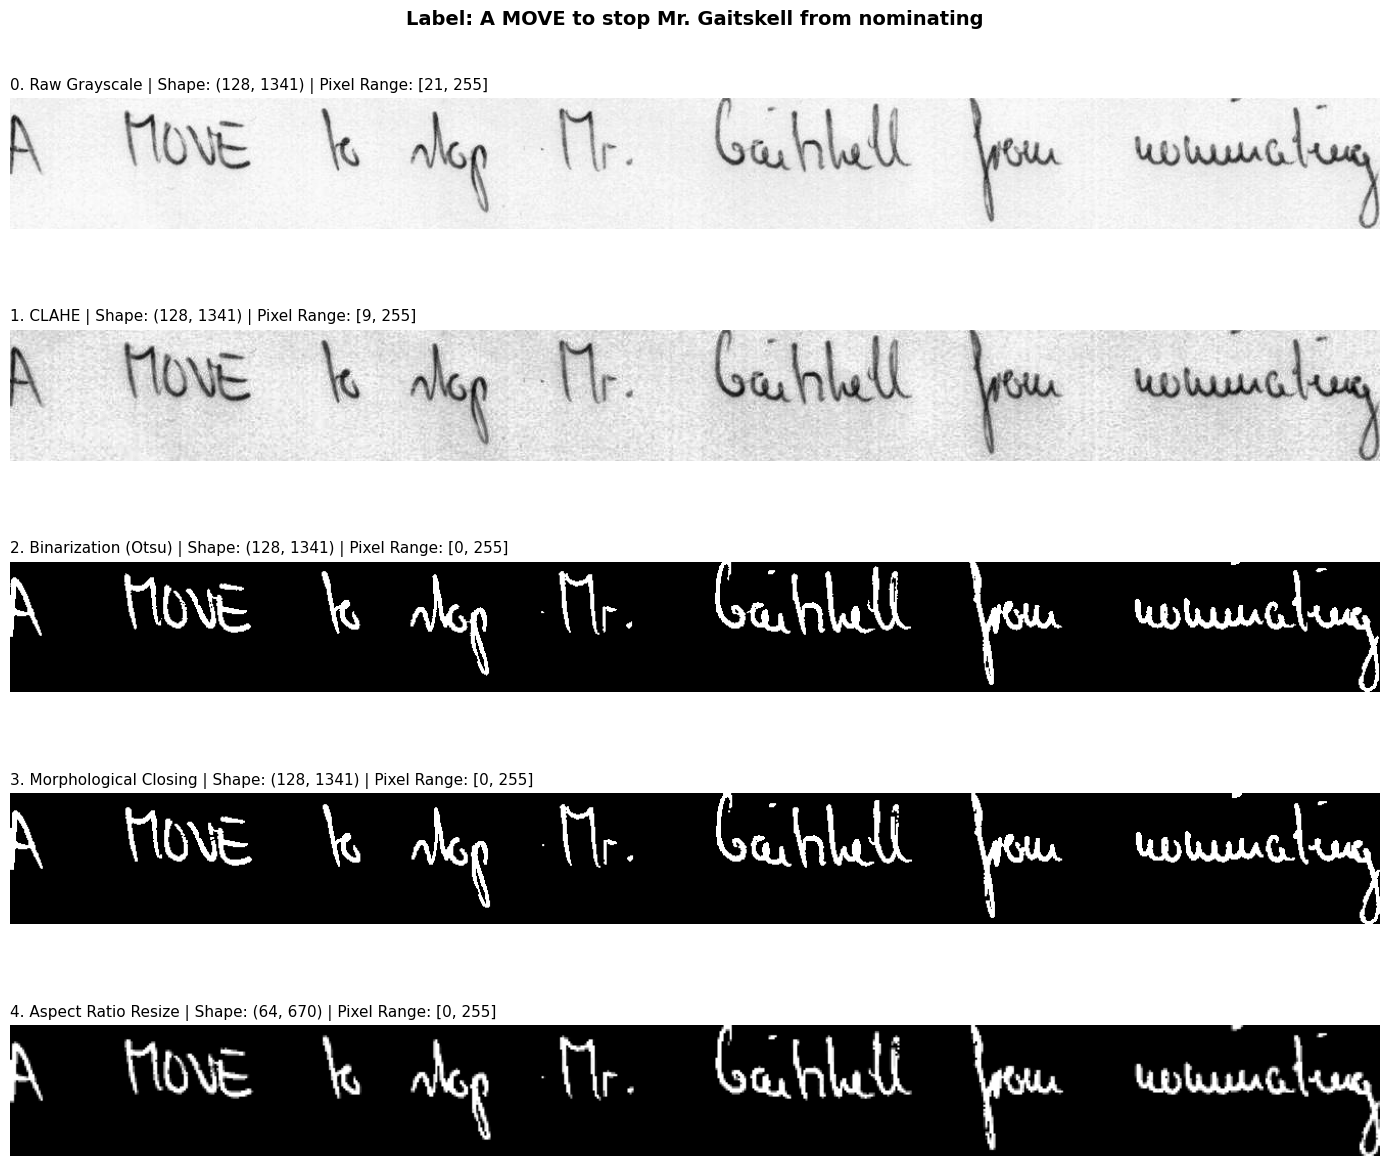

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Fetch raw image directly from the underlying dataset/dataframe
raw_pil_image = hf_dataset['train'][8]['image']
raw_label = hf_dataset['train'][8]['text']

# Convert raw PIL image to Grayscale NumPy array for OpenCV operations
raw_np_image = np.array(raw_pil_image.convert('L'))

# Define the 4 specified preprocessing/augmentation steps sequentially
augmentation_steps = [
    ("0. Raw Grayscale", lambda img: img.copy()),
    ("1. CLAHE", baseline_preprocessor.apply_contrast_normalization),
    ("2. Binarization (Otsu)", baseline_preprocessor.apply_binarization),
    ("3. Morphological Closing", baseline_preprocessor.apply_morphology),
    ("4. Aspect Ratio Resize", baseline_preprocessor.resize)
]

# Apply steps sequentially and store intermediate images
images_per_step = []
current_img = raw_np_image

for name, transform in augmentation_steps:
    current_img = transform(current_img)
    images_per_step.append((name, current_img))

# Plot each step stacked vertically
fig, axes = plt.subplots(len(augmentation_steps), 1, figsize=(14, 2.5 * len(augmentation_steps)))
fig.suptitle(f"Label: {raw_label}", fontsize=14, fontweight='bold')

for idx, (step_name, img_state) in enumerate(images_per_step):
    ax = axes[idx]

    # Handle both NumPy array and PyTorch Tensor outputs
    if isinstance(img_state, torch.Tensor):
        display_img = img_state.squeeze(0).cpu().numpy()
    else:
        display_img = img_state

    min_val, max_val = display_img.min(), display_img.max()
    subtitle = f"{step_name} | Shape: {display_img.shape} | Pixel Range: [{min_val}, {max_val}]"

    ax.imshow(display_img, cmap='gray')
    ax.set_title(subtitle, fontsize=11, loc='left')
    ax.axis('off')

plt.tight_layout()
plt.show()

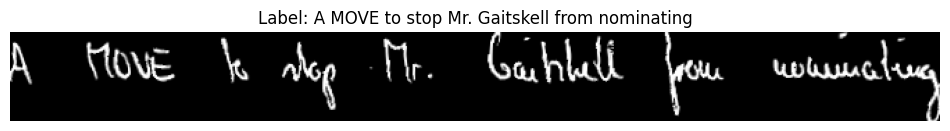

Tensor Shape: torch.Size([1, 64, 670])
Min Value: 0.00 (Should be ~0.0 for background)
Max Value: 1.00 (Should be ~1.0 for ink)


In [44]:
import matplotlib.pyplot as plt

# Grab a sample from the training dataset
sample_img_tensor, sample_label = train_dataset[8]

# Convert tensor back to numpy array for visualization (1, H, W -> H, W)
sample_img_np = sample_img_tensor.squeeze(0).numpy()

plt.figure(figsize=(12, 3))
plt.imshow(sample_img_np, cmap='gray')
plt.title(f"Label: {decode_label(sample_label.tolist())}")
plt.axis('off')
plt.show()

print(f"Tensor Shape: {sample_img_tensor.shape}")
print(f"Min Value: {sample_img_np.min():.2f} (Should be ~0.0 for background)")
print(f"Max Value: {sample_img_np.max():.2f} (Should be ~1.0 for ink)")

In [45]:
# Fetch a single batch from the train_loader
batch_images, batch_labels, batch_label_lengths = next(iter(train_loader))

print("=== Collate Test ===")
print(f"Batch Images Tensor Shape: {batch_images.shape}")  # Should be (32, 1, 64, max_w_in_batch)
print(f"Concatenated Labels Shape: {batch_labels.shape}")
print(f"Label Lengths Vector: {batch_label_lengths}")

# Check padding value in the rightmost region of a padded image
padded_region = batch_images[0, 0, :, -10:]
assert torch.all(padded_region == 0.0), "Padding error: Background padding is not 0.0!"
print("--> Collate batch padding passed!")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== Collate Test ===
Batch Images Tensor Shape: torch.Size([32, 1, 64, 1024])
Concatenated Labels Shape: torch.Size([1435])
Label Lengths Vector: tensor([45, 45, 38, 50, 41,  7, 58, 38, 26, 46, 51, 57, 57, 50, 68, 47, 33, 46,
        44, 44, 43, 43, 40, 57, 38, 43, 54, 41, 43, 55, 42, 45])
--> Collate batch padding passed!


## **Step 7: Save Preprocessing Artifacts**

In [46]:
all_chars = set("".join(train_df['label'].dropna()))
missing_chars = all_chars - set(char_to_idx.keys())
if missing_chars:
    print(f"Adding missing characters to CHARSET: {missing_chars}")
    # Append missing characters to CHARSET and rebuild char_to_idx / NUM_CLASSES

In [47]:
vocab_payload = {
    "char_to_idx": char_to_idx,
    "idx_to_char": {str(k): v for k, v in idx_to_char.items()},
    "num_classes": NUM_CLASSES,
}
with open("char_vocab.json", "w") as f:
    json.dump(vocab_payload, f, indent=2)

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)

print("--> Part 1 complete. Saved char_vocab.json, train.csv, val.csv")

--> Part 1 complete. Saved char_vocab.json, train.csv, val.csv


# **Part 2 - Model Architectures**

## **Pathway A - CRNN**

Height collapses via `AdaptiveAvgPool2d((1, None))` (robust to whatever
`CHAR_HEIGHT` preprocessing actually used) while width is deliberately
downsampled less than height, so CTC has enough sequence length to align
against real words/sentences instead of just single characters.

In [48]:
class HybridCNNBackbone(nn.Module):
    def __init__(self, in_channels: int = 1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                      # H/2, W/2

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                      # H/4, W/4

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),            # H/8, W/4 (width preserved)

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),            # H/16, W/4 (width preserved)

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),

            # Collapse height to exactly 1 regardless of input height, keep width as-is.
            nn.AdaptiveAvgPool2d((1, None)),
        )

    def forward(self, x):
        return self.features(x)


class PathwayACRNN(nn.Module):
    def __init__(self, num_classes: int, in_channels: int = 1, hidden_size: int = 256, lstm_layers: int = 2):
        super().__init__()
        self.backbone = HybridCNNBackbone(in_channels=in_channels)
        self.lstm = nn.LSTM(input_size=512, hidden_size=hidden_size,
                             num_layers=lstm_layers, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        conv_out = self.backbone(x)          # (B, C=512, H=1, W')
        conv_out = conv_out.squeeze(2)        # (B, C, W')
        conv_out = conv_out.permute(2, 0, 1)  # (W'=seq_len, B, C) — what nn.LSTM expects
        lstm_out, _ = self.lstm(conv_out)
        logits = self.fc(lstm_out)            # (seq_len, B, num_classes)
        return logits



# **Part 3 - Metric Engine**

Levenshtein edit distance, CER, WER, and CTC greedy decoding: generic over vocabulary size.

In [49]:
# Computes exact Levenshtein edit distance between two sequences
def levenshtein_distance(seq1, seq2):
    m, n = len(seq1), len(seq2)
    dp = np.zeros((m + 1, n + 1), dtype=int)
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq1[i - 1] == seq2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(dp[i - 1][j], dp[i][j - 1], dp[i - 1][j - 1])
    return dp[m][n]

# Character Error Rate, as a percentage
def compute_cer(predictions, targets):
    total_dist, total_chars = 0, 0
    for pred, target in zip(predictions, targets):
        total_dist += levenshtein_distance(list(pred), list(target))
        total_chars += max(len(target), 1)
    return (total_dist / total_chars) * 100.0


# Word Error Rate, as a percentage
def compute_wer(predictions, targets):
    total_dist, total_words = 0, 0
    for pred, target in zip(predictions, targets):
        pred_words = pred.strip().split()
        target_words = target.strip().split()
        total_dist += levenshtein_distance(pred_words, target_words)
        total_words += max(len(target_words), 1)
    return (total_dist / total_words) * 100.0


# Decodes raw CTC output logits (seq_len, batch, num_classes) into strings.
def ctc_decode_greedy(outputs, idx_to_char):
    _, max_indices = torch.max(outputs, dim=2)
    max_indices = max_indices.transpose(0, 1)  # (batch, seq_len)

    decoded_strings = []
    for i in range(max_indices.size(0)):
        raw_pred = max_indices[i].tolist()
        decoded_chars = []
        prev_token = -1
        for token in raw_pred:
            if token != 0 and token != prev_token:
                decoded_chars.append(idx_to_char.get(token, ''))
            prev_token = token
        decoded_strings.append("".join(decoded_chars))
    return decoded_strings

# **Part 4 - Training**

## **Pathway A (CRNN) Training Loop**

In [50]:
def train_crnn(model, train_loader, val_loader, epochs=5, lr=1e-3, weight_decay=1e-3,
                max_eval_batches=None, checkpoint_path=None, resume=True):
    model.to(device)
    criterion = nn.CTCLoss(blank=0, zero_infinity=True)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=2, T_mult=2, eta_min=1e-5)

    start_epoch = 0
    history = {"train_loss": [], "val_cer": [], "val_wer": []}

    if resume and checkpoint_path and os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        start_epoch = ckpt["epoch"]
        history = ckpt.get("history", history)
        print(f"--> Resumed from checkpoint at epoch {start_epoch} ({checkpoint_path})")

    if start_epoch >= epochs:
        print(f"--> Checkpoint already at epoch {start_epoch}, target is {epochs} -- nothing to do. "
              f"Raise `epochs` to continue training.")
        return model, history

    print(f"--> Starting Pathway A (CRNN) training on {device} "
          f"(epoch {start_epoch + 1} -> {epochs})...")

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss = 0.0

        for images, labels, label_lengths in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [CRNN Train]"):
            images = images.to(device)
            labels = labels.to(device)
            label_lengths = label_lengths.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # (seq_len, B, num_classes)

            # Real per-sample target lengths -- this is the fix. The old version
            # hardcoded this to a tensor of all-1s regardless of actual label length.
            input_lengths = torch.full((images.size(0),), outputs.size(0), dtype=torch.long, device=device)

            loss = criterion(outputs.log_softmax(2), labels, input_lengths, label_lengths)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()
        avg_loss = running_loss / len(train_loader)
        val_cer, val_wer = evaluate_crnn(model, val_loader, max_batches=max_eval_batches)

        history["train_loss"].append(avg_loss)
        history["val_cer"].append(val_cer)
        history["val_wer"].append(val_wer)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Val CER: {val_cer:.2f}% | Val WER: {val_wer:.2f}% | "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")

        if checkpoint_path:
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "history": history,
            }, checkpoint_path)
            print(f"--> Checkpoint saved -> {checkpoint_path}")

    print("--> Pathway A training complete.\n")
    return model, history


def evaluate_crnn(model, val_loader, max_batches=None):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch_idx, (images, labels, label_lengths) in enumerate(val_loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            images = images.to(device)
            outputs = model(images)
            preds = ctc_decode_greedy(outputs, idx_to_char)

            targets = []
            offset = 0
            for length in label_lengths.tolist():
                targets.append(decode_label(labels[offset:offset + length].tolist()))
                offset += length

            all_preds.extend(preds)
            all_targets.extend(targets)

    return compute_cer(all_preds, all_targets), compute_wer(all_preds, all_targets)

def evaluate_test_set(model_path=CRNN_CHECKPOINT_FILE, vocab_path="char_vocab.json", batch_size=32):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"--> Running Evaluation on device: {device}")

    # Load Vocabulary
    with open(vocab_path, "r") as f:
        vocab_payload = json.load(f)
    idx_to_char = {int(k): v for k, v in vocab_payload["idx_to_char"].items()}
    char_to_idx = vocab_payload["char_to_idx"]
    num_classes = vocab_payload["num_classes"]

    # Load Test Dataset from Hugging Face Teklia/IAM-line
    print("--> Loading Teklia/IAM-line test split...")
    hf_dataset = load_dataset("Teklia/IAM-line", split="test")
    test_df = hf_dataset.to_pandas().rename(columns={'text': 'label'})
    print(f"--> Total Test Samples: {len(test_df)}")

    # Initialize DataLoader
    preprocessor = BaselinePreprocessor(target_height=64, max_width=1024)
    test_dataset = TestHandwritingDataset(test_df, preprocessor=preprocessor, char_to_idx=char_to_idx)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=2, pin_memory=True, collate_fn=test_collate_fn)

    # Load Trained Model
    model = PathwayACRNN(num_classes=num_classes)
    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"--> Loaded model weights from: {model_path}")

    # Initialize Decoders
    labels = [idx_to_char.get(i, "") for i in range(num_classes)]
    labels[0] = ""
    beam_decoder = build_ctcdecoder(labels=labels)
    spell = SpellChecker()

    greedy_preds, beam_preds, beam_spell_preds = [], [], []
    ground_truths = []

    print("--> Evaluating test set...")
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc="Evaluating Batches"):
            images = images.to(device)
            outputs = model(images)  # Shape: (seq_len, batch_size, num_classes)

            # 1. Greedy Decoding
            _, max_indices = torch.max(outputs, dim=2)
            max_indices = max_indices.transpose(0, 1)
            for i in range(max_indices.size(0)):
                raw_pred = max_indices[i].tolist()
                decoded_chars, prev_token = [], -1
                for token in raw_pred:
                    if token != 0 and token != prev_token:
                        decoded_chars.append(idx_to_char.get(token, ''))
                    prev_token = token
                greedy_preds.append("".join(decoded_chars))

            # 2. Beam Search & Spellcheck Decoding
            probs = F.softmax(outputs, dim=-1).permute(1, 0, 2).detach().cpu().numpy()
            for sample_probs in probs:
                beam_text = beam_decoder.decode(sample_probs)
                beam_preds.append(beam_text)

                # Spellcheck Correction
                words = beam_text.split()
                corrected = [spell.correction(w) or w if w.isalpha() else w for w in words]
                beam_spell_preds.append(" ".join(corrected))

            ground_truths.extend(targets)

    # Calculate Benchmark Metrics
    greedy_cer, greedy_wer = compute_cer(greedy_preds, ground_truths), compute_wer(greedy_preds, ground_truths)
    beam_cer, beam_wer = compute_cer(beam_preds, ground_truths), compute_wer(beam_preds, ground_truths)
    spell_cer, spell_wer = compute_cer(beam_spell_preds, ground_truths), compute_wer(beam_spell_preds, ground_truths)

    # Display Metrics Table
    print("\n" + "=" * 65)
    print(f"{'Decoding Strategy':<28} | {'CER (%)':<12} | {'WER (%)':<12}")
    print("=" * 65)
    print(f"{'Greedy Decoding':<28} | {greedy_cer:<12.2f} | {greedy_wer:<12.2f}")
    print(f"{'CTC Beam Search':<28} | {beam_cer:<12.2f} | {beam_wer:<12.2f}")
    print(f"{'Beam Search + Spellcheck':<28} | {spell_cer:<12.2f} | {spell_wer:<12.2f}")
    print("=" * 65 + "\n")

    # Sample Output Inspection
    print("--- Ground Truth vs Predictions (First 3 Samples) ---")
    for i in range(min(3, len(ground_truths))):
        print(f"Target:        {ground_truths[i]}")
        print(f"Greedy:        {greedy_preds[i]}")
        print(f"Beam+Spell:    {beam_spell_preds[i]}\n")

## **Post-Training Optimization - Quantization & Latency Benchmarking**

In [51]:
def quantize_crnn_model(fp32_model):
    print("--> Applying dynamic INT8 quantization to Pathway A (CRNN)...")
    cpu_model = fp32_model.to('cpu').eval()
    quantized_model = torch.quantization.quantize_dynamic(
        cpu_model, {nn.LSTM, nn.Linear}, dtype=torch.qint8
    )
    print("--> Model successfully quantized to INT8.")
    return quantized_model


def benchmark_inference(fp32_model, int8_model, input_shape=(1, 1, CHAR_HEIGHT, MAX_WIDTH), num_runs=100):
    import time  # local import: keeps this function runnable even if cells above weren't re-run this session
    print("--> Running inference latency benchmarks on CPU...")
    dummy_input = torch.randn(input_shape).to('cpu')

    for _ in range(10):
        _ = fp32_model(dummy_input)
        _ = int8_model(dummy_input)

    start_time = time.perf_counter()
    with torch.no_grad():
        for _ in range(num_runs):
            _ = fp32_model(dummy_input)
    fp32_latency = ((time.perf_counter() - start_time) / num_runs) * 1000.0

    start_time = time.perf_counter()
    with torch.no_grad():
        for _ in range(num_runs):
            _ = int8_model(dummy_input)
    int8_latency = ((time.perf_counter() - start_time) / num_runs) * 1000.0

    speedup = fp32_latency / int8_latency
    print("\n=================== INFERENCE BENCHMARK METRICS ===================")
    print(f"FP32 Baseline Latency    : {fp32_latency:.3f} ms / image")
    print(f"INT8 Quantized Latency   : {int8_latency:.3f} ms / image")
    print(f"Latency Reduction Factor : {speedup:.2f}x speedup")
    print("===================================================================\n")

## **Pipeline Execution**

In [52]:
crnn_test_model = PathwayACRNN(num_classes=NUM_CLASSES).to(device)
crnn_test_model.eval()

with torch.no_grad():
    test_images = batch_images.to(device)
    logits = crnn_test_model(test_images)

seq_len, batch_size, num_classes = logits.shape
print("\n=== Model Output Test ===")
print(f"Logits Output Shape (seq_len, batch, classes): {logits.shape}")

# Verify CTC constraint: Sequence Length >= Max Label Length in Batch
max_label_len = batch_label_lengths.max().item()
assert seq_len >= max_label_len, f"CTC Failure! Model output sequence ({seq_len}) is shorter than target label ({max_label_len}). Increase MAX_WIDTH or reduce horizontal downsampling."

print(f"--> Sequence length ({seq_len}) >= Max label length ({max_label_len}). CTC alignment valid!")


=== Model Output Test ===
Logits Output Shape (seq_len, batch, classes): torch.Size([256, 32, 80])
--> Sequence length (256) >= Max label length (68). CTC alignment valid!


In [53]:
CRNN_EPOCHS = 35

# --- Pathway A: CRNN ---------------------------------------------------------
if os.path.exists(CRNN_CHECKPOINT_FILE):
    print(f"--> {CRNN_CHECKPOINT_FILE} already exists -- skipping training. "
          f"Delete it (or change CRNN_CHECKPOINT_FILE) to force retraining.")
    crnn_model = PathwayACRNN(num_classes=NUM_CLASSES)
    crnn_model.load_state_dict(torch.load(CRNN_CHECKPOINT_FILE, map_location=device))
    crnn_history = None
else:
    crnn_model = PathwayACRNN(num_classes=NUM_CLASSES)
    crnn_model, crnn_history = train_crnn(
        crnn_model, train_loader, val_loader, epochs=CRNN_EPOCHS, lr=1e-3,
        checkpoint_path=CRNN_TRAINING_CHECKPOINT_FILE, resume=False
    )
    print("\n=================== PATHWAY A (CRNN) RESULT ===================")
    print(f"Val CER: {crnn_history['val_cer'][-1]:.2f}% | Val WER: {crnn_history['val_wer'][-1]:.2f}%")
    print("=================================================================\n")

    # --- Post-training optimization ------------------------------------------
    int8_crnn = quantize_crnn_model(crnn_model)
    benchmark_inference(crnn_model, int8_crnn)

    # --- Save checkpoints ------------------------------------------------------
    torch.save(crnn_model.state_dict(), CRNN_CHECKPOINT_FILE)
    torch.save(int8_crnn.state_dict(), CRNN_INT8_CHECKPOINT_FILE)
    print(f"--> Saved {CRNN_CHECKPOINT_FILE}, {CRNN_INT8_CHECKPOINT_FILE}")


--> checkpoints/crnn_model.pt already exists -- skipping training. Delete it (or change CRNN_CHECKPOINT_FILE) to force retraining.


# **Part 5 - Inference Demo**

Line segmentation (with the internal-density-dip fix verified against real
test images during this project), preprocessing-consistent inference, and a
Gradio app.

Model loading below is resilient to session state: it reuses `crnn_model`/
`vit_model` directly if Part 4 already ran in this same kernel session, or
loads from the saved checkpoint files on disk otherwise (e.g. after a runtime
restart, or if you're re-running just this part later). If no trained Pathway
B weights exist either way, a fresh untrained instance is created so the
pathway toggle in the app doesn't crash.

In [54]:
!pip install -q pyctcdecode pyspellchecker


In [55]:
import torch.nn.functional as F
from pyctcdecode import build_ctcdecoder
from spellchecker import SpellChecker

# Build ordered label list for pyctcdecode (index 0 = CTC blank)
labels = [idx_to_char.get(i, "") for i in range(NUM_CLASSES)]
labels[0] = ""  # CTC blank token

# Initialize decoder and spellchecker once globally
ctc_decoder = build_ctcdecoder(labels=labels)
spell_checker = SpellChecker()

In [56]:
if 'crnn_model' not in globals():
    print("--> crnn_model not in memory (fresh session?) -- loading from disk instead.")
    crnn_model = PathwayACRNN(num_classes=NUM_CLASSES)
    if os.path.exists(CRNN_CHECKPOINT_FILE):
        crnn_model.load_state_dict(torch.load(CRNN_CHECKPOINT_FILE, map_location=device))
        print(f"--> Loaded CRNN weights from {CRNN_CHECKPOINT_FILE}")
    else:
        print(f"--> WARNING: {CRNN_CHECKPOINT_FILE} not found -- CRNN is UNTRAINED. "
              "Run Part 4 (Pipeline Execution) first, or place a trained "
              "checkpoint at that path.")

crnn_model.to(device).eval()
print("--> CRNN ready")


--> CRNN ready


In [57]:
with open(VIT_VOCAB_FILE, "r") as f:
    htr_vocab = json.load(f)

htr_char_to_idx = htr_vocab["char2idx"]
htr_idx_to_char = {v: k for k, v in htr_char_to_idx.items()}
HTR_BLANK_IDX = htr_vocab["blank_idx"]  # NOT 0, unlike the CRNN's vocab
HTR_NUM_CLASSES = len(htr_char_to_idx) + 1

print(f"--> HTR-VT vocab loaded from {VIT_VOCAB_FILE}: {HTR_NUM_CLASSES} classes, "
      f"blank at index {HTR_BLANK_IDX}")


--> HTR-VT vocab loaded from checkpoints/vocab.json: 80 classes, blank at index 79


In [58]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=(1, 1)):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        needs_downsample = stride != (1, 1) or in_ch != out_ch
        self.downsample = None
        if needs_downsample:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


class HTRVTBackbone(nn.Module):
    """Truncated ResNet-18 (layer4 removed) + 1x1 projection to transformer dim.
    Height-only stride in layer1/2/3 is a best-guess from weight shapes alone --
    verify with the shape-check cell below before trusting predictions."""
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
        )
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = nn.Sequential(ResBlock(64, 64, stride=(2, 1)), ResBlock(64, 64))
        self.layer2 = nn.Sequential(ResBlock(64, 128, stride=(2, 1)), ResBlock(128, 128))
        self.layer3 = nn.Sequential(ResBlock(128, 256, stride=(2, 1)), ResBlock(256, 256))

        self.proj = nn.Conv2d(256, 768, kernel_size=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 128))  # locks output to what pos_embed expects

    def forward(self, x):
        x = self.relu(self.stem(x))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.proj(x)
        x = self.adaptive_pool(x)          # (B, 768, 1, 128)
        return x.squeeze(2).permute(2, 0, 1)  # (128, B, 768) -- seq_len, batch, dim


class HTRVTBlock(nn.Module):
    def __init__(self, dim=768, heads=6, mlp_dim=3072):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, mlp_dim), nn.GELU(), nn.Linear(mlp_dim, dim))

    def forward(self, x):
        n = self.norm1(x)
        attn_out, _ = self.attn(n, n, n)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class PosEmbed(nn.Module):
    def __init__(self, seq_len=128, dim=768):
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(seq_len, dim))  # overwritten by load_state_dict

    def forward(self, x):
        return x + self.pe.unsqueeze(1)  # broadcast over batch


class HTRVTModel(nn.Module):
    def __init__(self, num_classes=HTR_NUM_CLASSES, layers=4):
        super().__init__()
        self.cnn = HTRVTBackbone()
        self.pos_embed = PosEmbed()
        self.encoder = nn.ModuleDict({"layers": nn.ModuleList([HTRVTBlock() for _ in range(layers)])})
        self.head = nn.ModuleDict({"head": nn.Linear(768, num_classes)})

    def forward(self, x):
        feats = self.cnn(x)              # (128, B, 768)
        feats = self.pos_embed(feats)
        for block in self.encoder["layers"]:
            feats = block(feats)
        return self.head["head"](feats)  # (128, B, num_classes)

In [59]:
htr_vt_model = HTRVTModel()
ckpt = torch.load(VIT_CHECKPOINT_FILE, map_location=device)

weights = ckpt.get("ema_state_dict", ckpt["model_state_dict"])
weights = {k: v for k, v in weights.items() if not k.startswith("span_mask")}  # training-only, unused at inference

missing, unexpected = htr_vt_model.load_state_dict(weights, strict=False)
print(f"--> Loaded {VIT_CHECKPOINT_FILE} | Missing: {len(missing)} | Unexpected: {len(unexpected)}")
if missing or unexpected:
    print("  missing:", missing[:10])
    print("  unexpected:", unexpected[:10])

htr_vt_model.to(device).eval()


--> Loaded checkpoints/best_vit.pt | Missing: 0 | Unexpected: 0


HTRVTModel(
  (cnn): HTRVTBackbone(
    (stem): Sequential(
      (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): ResBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(2, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affin

In [60]:
def ctc_decode_greedy_htr(outputs, idx_to_char, blank_idx):
    _, max_indices = torch.max(outputs, dim=2)
    max_indices = max_indices.transpose(0, 1)
    decoded = []
    for i in range(max_indices.size(0)):
        chars, prev = [], -1
        for token in max_indices[i].tolist():
            if token != blank_idx and token != prev:
                chars.append(idx_to_char.get(token, ''))
            prev = token
        decoded.append("".join(chars))
    return decoded

In [61]:
with torch.no_grad():
    dummy = torch.zeros(1, 1, CHAR_HEIGHT, MAX_WIDTH).to(device)
    out = htr_vt_model(dummy)
    print("Output shape:", out.shape, "-- expected (128, 1, 80)")

Output shape: torch.Size([128, 1, 80]) -- expected (128, 1, 80)


In [62]:
images, labels, label_lengths = next(iter(val_loader))
images = images.to(device)
inverted_images = 1.0 - images   # flip ink/background polarity to match "Inverted black background"

with torch.no_grad():
    outputs = htr_vt_model(inverted_images[:5])
preds = ctc_decode_greedy_htr(outputs, htr_idx_to_char, HTR_BLANK_IDX)

offset = 0
for i, length in enumerate(label_lengths[:5].tolist()):
    target = decode_label(labels[offset:offset+length].tolist())
    print(f"target: {target!r:20s} pred: {preds[i]!r}")
    offset += length

target: 'It was a splendid interpretation of the' pred: 'It was a spledid intempetation of that'
target: 'sympathetic C O . Paul Daneman gave another' pred: 'sympathetie C D . Sul abanemae garve another'
target: 'part . The rest of the cast were well chosen ,' pred: 'part . The rest of the cst wre sell chosn '
target: 'with James Maxwell making a fine job of the' pred: 'with James elaserell mating a fine job of the'
target: '" The Little Key . "' pred: '" The itle ley . '


In [63]:
iam_line_ds = load_dataset("Teklia/IAM-line")


In [64]:
def evaluate_htr_vt(val_loader, max_batches=5):
    all_preds, all_targets = [], []
    for batch_idx, (images, labels, label_lengths) in enumerate(val_loader):
        if batch_idx >= max_batches:
            break
        images = images.to(device)
        inverted = 1.0 - images
        with torch.no_grad():
            outputs = htr_vt_model(inverted)
        preds = ctc_decode_greedy_htr(outputs, htr_idx_to_char, HTR_BLANK_IDX)

        offset = 0
        for length in label_lengths.tolist():
            all_targets.append(decode_label(labels[offset:offset+length].tolist()))
            offset += length
        all_preds.extend(preds)

    print(f"CER: {compute_cer(all_preds, all_targets):.2f}%  |  WER: {compute_wer(all_preds, all_targets):.2f}%")

evaluate_htr_vt(val_loader)

CER: 14.47%  |  WER: 46.86%


## **Line Segmentation + Recognition Pipeline**

In [65]:
def to_grayscale(image_input) -> np.ndarray:
    if isinstance(image_input, str):
        img = cv2.imread(image_input, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Could not load image at {image_input}")
        return img

    arr = np.array(image_input)
    if arr.ndim == 2:
        return arr.astype(np.uint8)
    if arr.shape[2] == 4:
        arr = arr[:, :, :3]
    return cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)


def segment_into_lines(gray_img: np.ndarray, min_line_height: int = 15, merge_gap: int = 10):
    _, thresh = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    dilated = cv2.dilate(thresh, np.ones((15, 1), np.uint8), iterations=1)

    row_sums = np.sum(dilated, axis=1)
    density_threshold = gray_img.shape[1] * 0.02

    raw_bounds = []
    in_line = False
    start_y = 0
    for y, count in enumerate(row_sums):
        if count > density_threshold and not in_line:
            in_line = True
            start_y = y
        elif count <= density_threshold and in_line:
            in_line = False
            raw_bounds.append((start_y, y))

    if in_line:
        raw_bounds.append((start_y, gray_img.shape[0]))

    merged_bounds = []
    for (y0, y1) in raw_bounds:
        if merged_bounds and (y0 - merged_bounds[-1][1]) <= merge_gap:
            merged_bounds[-1] = (merged_bounds[-1][0], y1)
        else:
            merged_bounds.append((y0, y1))

    line_bounds = [(y0, y1) for (y0, y1) in merged_bounds if (y1 - y0) >= min_line_height]

    if not line_bounds:
        line_bounds = [(0, gray_img.shape[0])]

    return [gray_img[y0:y1, :] for (y0, y1) in line_bounds], line_bounds


print("--> Segmentation utilities ready.")

--> Segmentation utilities ready.


In [66]:
def recognize_line(line_img: np.ndarray, pathway: str = "crnn", decode_method: str = "Beam Search + Spellcheck") -> str:
    processed = baseline_preprocessor(line_img)

    if pathway == "crnn":
        tensor = torch.from_numpy(processed).unsqueeze(0).unsqueeze(0).float() / 255.0
        tensor = tensor.to(device)

        with torch.no_grad():
            outputs = crnn_model(tensor)  # Shape: (seq_len, batch_size=1, num_classes)

        # Option A: Fast Greedy CTC Decoding
        if decode_method == "Greedy":
            return ctc_decode_greedy(outputs, idx_to_char)[0]

        # Option B / C: Beam Search via pyctcdecode
        # Convert logits (seq_len, 1, num_classes) -> softmax probabilities (seq_len, num_classes)
        probs = F.softmax(outputs, dim=-1).squeeze(1).detach().cpu().numpy()
        decoded_text = ctc_decoder.decode(probs)

        # Option C: Beam Search + Spellcheck
        if decode_method == "Beam Search + Spellcheck":
            words = decoded_text.split()
            corrected_words = [
                spell_checker.correction(w) or w if w.isalpha() else w
                for w in words
            ]
            decoded_text = " ".join(corrected_words)

        return decoded_text

    else:
        inverted = 255 - processed  # ink=high value, background=0 -- matches this checkpoint's training convention
        padded = np.full((CHAR_HEIGHT, MAX_WIDTH), 0, dtype=np.uint8)
        w = min(inverted.shape[1], MAX_WIDTH)
        padded[:, :w] = inverted[:, :w]
        tensor = torch.from_numpy(padded).unsqueeze(0).unsqueeze(0).float() / 255.0
        tensor = tensor.to(device)

        with torch.no_grad():
            outputs = htr_vt_model(tensor)
        return ctc_decode_greedy_htr(outputs, htr_idx_to_char, HTR_BLANK_IDX)[0]


def recognize_handwriting(image, pathway: str = "crnn", decode_method: str = "Beam Search + Spellcheck", min_line_height: int = 15):
    """Full pipeline: image -> line crops -> decoding method -> output text."""
    if image is None:
        return "", []

    gray = to_grayscale(image)
    line_imgs, _ = segment_into_lines(gray, min_line_height=min_line_height)

    lines_text = [
        recognize_line(line_img, pathway=pathway, decode_method=decode_method)
        for line_img in line_imgs
    ]
    return "\n".join(lines_text), line_imgs

In [67]:
class TestHandwritingDataset(Dataset):
    def __init__(self, dataframe, preprocessor=None, char_to_idx=None):
        self.df = dataframe.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.char_to_idx = char_to_idx

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        raw_img = row['image']

        if isinstance(raw_img, dict) and 'bytes' in raw_img:
            nparr = np.frombuffer(raw_img['bytes'], np.uint8)
            image = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)
        elif hasattr(raw_img, 'convert'):
            image = np.array(raw_img.convert('L'))
        else:
            image = np.array(raw_img, dtype=np.uint8)

        if self.preprocessor:
            image = self.preprocessor(image)

        image_tensor = torch.from_numpy(image).unsqueeze(0).float() / 255.0
        return image_tensor, row['label']


def test_collate_fn(batch):
    images, labels = zip(*batch)
    target_height = images[0].shape[1]
    max_width = max(img.shape[2] for img in images)

    padded_images = torch.zeros(len(images), 1, target_height, max_width)
    for i, img in enumerate(images):
        padded_images[i, :, :, :img.shape[2]] = img

    return padded_images, list(labels)


## Gradio App

In [68]:
import gradio as gr

def gradio_predict(image, pathway_choice, decode_method, min_line_height):
    pathway = "crnn" if pathway_choice.startswith("Pathway A") else "vit"

    text, line_imgs = recognize_handwriting(
        image,
        pathway=pathway,
        decode_method=decode_method,
        min_line_height=int(min_line_height)
    )

    gallery_items = [
        (line_img, f"Line {i+1} ({line_img.shape[1]}x{line_img.shape[0]}px)")
        for i, line_img in enumerate(line_imgs)
    ]
    return text, gallery_items


with gr.Blocks(title="Handwriting Recognition Demo") as demo:
    gr.Markdown("# Handwriting Recognition (Line-Level CRNN + CTC Beam Search)")

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="numpy", label="Handwriting Image")

            pathway_choice = gr.Radio(
                ["Pathway A (CRNN — fast)", "Pathway B (HTR-VT — slower)"],
                value="Pathway A (CRNN — fast)",
                label="Model Architecture"
            )

            decode_method = gr.Radio(
                ["Greedy", "Beam Search", "Beam Search + Spellcheck"],
                value="Beam Search + Spellcheck",
                label="CTC Decoding Method"
            )

            min_line_height = gr.Slider(
                5, 60, value=15, step=1,
                label="Minimum line height (px)"
            )

            submit_btn = gr.Button("Recognize Text", variant="primary")

        with gr.Column():
            text_output = gr.Textbox(label="Recognized Text", lines=10)
            line_gallery = gr.Gallery(label="Detected Line Segments", columns=1, height=300)

    submit_btn.click(
        fn=gradio_predict,
        inputs=[image_input, pathway_choice, decode_method, min_line_height],
        outputs=[text_output, line_gallery]
    )

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b201c38918a05dab19.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b201c38918a05dab19.gradio.live
